Epoch 1/5 | Training Loss: 2.2993 | Test Loss: 2.2990 | Accuracy: 13.03%


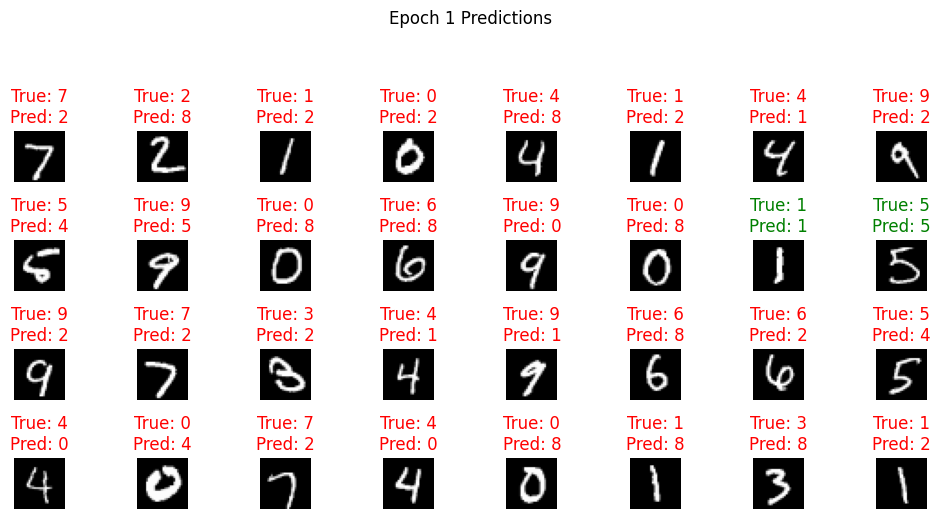

Epoch 2/5 | Training Loss: 2.2993 | Test Loss: 2.2990 | Accuracy: 13.03%


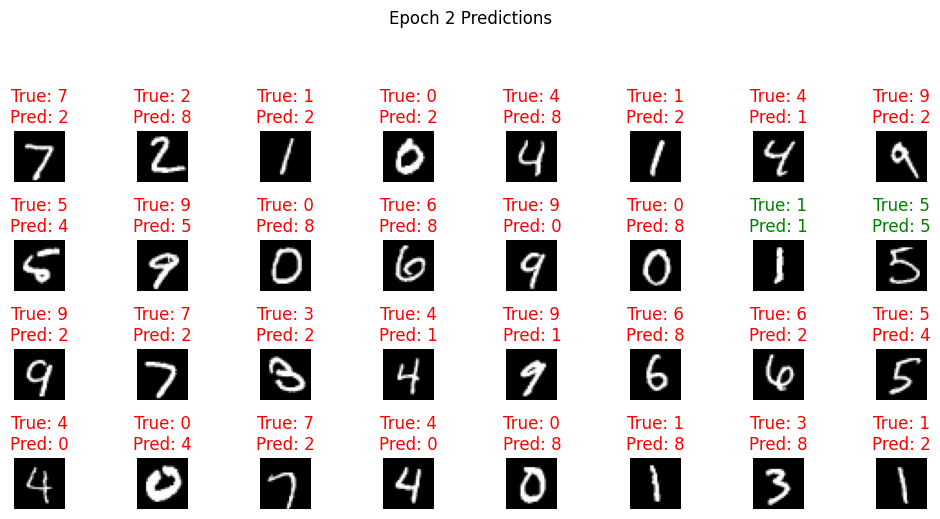

KeyboardInterrupt: 

In [3]:
import numpy as np
import DnnLib
import matplotlib.pyplot as plt
import json
import random
import time

start = time.time()

# Carga y preparación de los datos
model = {}
data_train = np.load("mnist_train.npz")
data_test = np.load("mnist_test.npz")

with open("mnist_untrained_mlp.json", "r") as f:
    model = json.load(f)

scale = model['preprocess']

train_images = data_train['images']
train_labels = data_train['labels']
test_images = data_test['images']
test_labels = data_test['labels']

test_loss_arr = []
accuracy_save = []

entries = np.array([img.flatten() / scale['scale'] for img in train_images])
test_entries = np.array([img.flatten() / scale['scale'] for img in test_images])

def one_hot_encode(labels, num_classes):
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot

num_classes = model['layers'][-1]['units']
one_hot_labels_train = one_hot_encode(train_labels, num_classes)
one_hot_labels_test = one_hot_encode(test_labels, num_classes)

layers = []
input_size = entries.shape[1]

for item in model['layers']:
    activation = None
    if item['activation'] == "relu":
        activation = DnnLib.ActivationType.RELU
    elif item['activation'] == "softmax":
        activation = DnnLib.ActivationType.SOFTMAX
    
    output_size = item['units']
    layer = DnnLib.DenseLayer(input_size, output_size, activation)
    
    # Inicialización de He para pesos
    if item['activation'] == "relu":
        weights = np.random.randn(input_size, output_size) * np.sqrt(2.0 / input_size)
    else:
        weights = np.random.randn(input_size, output_size) * 0.01
        
    layer.weights = weights
    layer.bias = np.zeros(output_size)
    
    layers.append(layer)
    input_size = output_size

# --- Funciones de Entrenamiento ---

def forward_pass(network, input_data):
    intermediate_values = []
    current_output = input_data
    for layer in network:
        intermediate_values.append({
            'input': current_output,
            'linear_output': np.dot(current_output, layer.weights) + layer.bias,
            'activation_type': layer.activation_type
        })
        current_output = DnnLib.apply_activation(intermediate_values[-1]['linear_output'], layer.activation_type)
    return current_output, intermediate_values

def categorical_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]
    return loss

learning_rate = 0.1
optimizer = DnnLib.Adam(
 learning_rate=0.1,
 beta1=0.9,
 beta2=0.999,
 epsilon=1e-8 
)


def backward_pass(network, y_true, y_pred, intermediate_values):
    grad = (y_pred - y_true) / y_true.shape[0]
    for i in reversed(range(len(network))):
        layer = network[i]
        
        values = intermediate_values[i]
        
        grad_activation = DnnLib.apply_activation_derivative(values['linear_output'], values['activation_type'])
        grad_before_activation = grad * grad_activation
        
        grad_weights = np.dot(values['input'].T, grad_before_activation)
        grad_bias = np.sum(grad_before_activation, axis=0)
        grad_learning_rate = learning_rate * np.sum(grad_before_activation, axis=0)
        
        grad = np.dot(grad_before_activation, layer.weights.T)
        optimizer.update(layer)
        
        
# Bucle de entrenamiento
epochs = 5
batch_size = 16
total_entries = len(entries)

for epoch in range(epochs):
    epoch_loss = 0
    permutation = np.random.permutation(total_entries)
    shuffled_entries = entries[permutation]
    shuffled_labels = one_hot_labels_train[permutation]

    for i in range(0, total_entries, batch_size):
        end = i + batch_size
        batch_x = shuffled_entries[i:end]
        batch_y = shuffled_labels[i:end]
        
        predictions, intermediate_values = forward_pass(layers, batch_x)
        loss = categorical_cross_entropy(batch_y, predictions)
        epoch_loss += loss
        backward_pass(layers, batch_y, predictions, intermediate_values)
        
    avg_loss = epoch_loss / (total_entries / batch_size)
    
    test_predictions, _ = forward_pass(layers, test_entries)
    test_loss = categorical_cross_entropy(one_hot_labels_test, test_predictions)
    predicted_classes = np.argmax(test_predictions, axis=1)
    true_classes = np.argmax(one_hot_labels_test, axis=1)
    accuracy = np.mean(predicted_classes == true_classes)
    
    accuracy_save.append(accuracy * 100)
    test_loss_arr.append(avg_loss)
    
    print(f"Epoch {epoch + 1}/{epochs} | Training Loss: {avg_loss:.4f} | Test Loss: {test_loss:.4f} | Accuracy: {accuracy * 100:.2f}%")

    # --- Visualización al final de cada época ---
    plt.figure(figsize=(10, 10))
    for i in range(32):
        plt.subplot(8, 8, i + 1)
        plt.imshow(test_images[i], cmap="gray")
        true_label = true_classes[i]
        pred_label = predicted_classes[i]
        title = f"True: {true_label}\nPred: {pred_label}"
        color = 'green' if true_label == pred_label else 'red'
        plt.title(title, color=color)
        plt.axis("off")
    plt.suptitle(f"Epoch {epoch + 1} Predictions")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

end = time.time()
length = end - start
print("Tiempo de Ejecución: ", length, " segundos!")

fig, ax = plt.subplots()
ax.plot(accuracy_save)
ax.set_xlabel("Iteraciones")
ax.set_ylabel("Precisión (%)")
ax.set_title("Rendimiento de Precisión")
ax.set_ylim(0, 100)
ax.grid(True)
plt.show()


# --- GUARDAR LOS PESOS Y SESGOS ENTRENADOS ---
trained_model = {}
trained_model['preprocess'] = model['preprocess']
trained_model['layers'] = []

for i, layer in enumerate(layers):
    layer_info = {
        'layer': i,
        'units': layer.weights.shape[1],
        'activation': model['layers'][i]['activation'],
        'W': layer.weights.tolist(),
        'b': layer.bias.tolist()
    }
    trained_model['layers'].append(layer_info)

with open('mnist_trained_mlp.json', 'w') as f:
    json.dump(trained_model, f, indent=4)

print("\nLos pesos y sesgos entrenados han sido guardados en 'mnist_trained_mlp.json'.")